# CS 451 – Advanced Machine Learning

# Spring, 2026

# INSTRUCTIONS
1. This is an individual assignment.
2. Only Jupyter Notebook format will be accepted.
3. The Python code required to complete this assignment, including the code supporting your
conclusions and answers, must be embedded in the jupyter notebook as “Mark Down” in the
corresponding answer as text (not as an image), unless otherwise specified. This code will be
marked. Unsolicited Python scripts submitted separately will not be marked.
4. Read carefully and answer all questions as requested. Any material or information unrelated to the
correct answer may result in a significant reduction of marks for that question.
5. Do not forget to fill in and sign the cover sheet, which must be the very first page of the PDF. Use
appropriate software to include the file at the beginning of your document.
6. If you need an extension or if your performance has been affected by extenuating circumstances,
you must follow the official special consideration procedure provided by your institution.
7. Only the techniques studied in this course will be accepted.
8. Understanding and interpreting the questions correctly is part of the assignment.

#PROBLEM

The nassCDS.csv file contains data on airbag and other influences on accident fatalities. The data has been
collected in the United States for 1997–2002, from police-reported car crashes in which there is a harmful
event (people or property), and from which at least one vehicle was towed. Data are restricted to front-seat
occupants, include only a subset of the variables recorded, and are restricted in other ways.

The dataset has 26,217 observations on the following 15 variables:

• dvcat: ordered factor with levels (estimated impact speeds) 1–9 km/h, 10–24, 25–39, 40–54, 55+

• weight: observation weights designed to account for varying sampling probabilities

• dead: factor with levels alive, dead (target variable)

• airbag: factor with levels none, airbag

• seatbelt: factor with levels none, belted

• frontal: numeric vector; 0 = non-frontal, 1 = frontal impact

• sex: factor with levels f, m

• ageOFocc: age of occupant in years

• yearacc: year of accident

• yearVeh: year of vehicle model

• abcat: airbag deployment status with levels deploy, nodeploy, unavail

• occRole: factor with levels driver, pass

• deploy: numeric vector; 0 = airbag unavailable or not deployed, 1 = deployed

• injSeverity: numeric vector; 0 = none, 1 = possible injury, 2 = no incapacity, 3 = incapacity, 4 =
killed, 5 = unknown, 6 = prior death

• caseid: unique vehicle identifier within each year

In this project, we are interested in explaining the probability of surviving (dead) given airbag, seatbelt,
frontal, sex, ageOFocc, yearVeh, and deploy.

In [206]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from scipy.stats import chi2_contingency, f_oneway
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.metrics import precision_recall_fscore_support


In [207]:
df = pd.read_csv('/content/nassCDS.csv')
df.head()

,rownames,dvcat,weight,dead,airbag,seatbelt,frontal,sex,ageOFocc,yearacc,yearVeh,abcat,occRole,deploy,injSeverity,caseid
0,1,25-39,25.069,alive,none,belted,1,f,26,1997,1990.0,unavail,driver,0,3.0,2:3:1
1,2,10-24,25.069,alive,airbag,belted,1,f,72,1997,1995.0,deploy,driver,1,1.0,2:3:2
2,3,10-24,32.379,alive,none,none,1,f,69,1997,1988.0,unavail,driver,0,4.0,2:5:1
3,4,25-39,495.444,alive,airbag,belted,1,f,53,1997,1995.0,deploy,driver,1,1.0,2:10:1
4,5,25-39,25.069,alive,none,belted,1,f,32,1997,1988.0,unavail,driver,0,3.0,2:11:1


In [208]:
df.isnull().sum()

,0
rownames,0
dvcat,0
weight,0
dead,0
airbag,0
seatbelt,0
frontal,0
sex,0
ageOFocc,0
yearacc,0


In [209]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26217 entries, 0 to 26216
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   rownames     26217 non-null  int64  
 1   dvcat        26217 non-null  object 
 2   weight       26217 non-null  float64
 3   dead         26217 non-null  object 
 4   airbag       26217 non-null  object 
 5   seatbelt     26217 non-null  object 
 6   frontal      26217 non-null  int64  
 7   sex          26217 non-null  object 
 8   ageOFocc     26217 non-null  int64  
 9   yearacc      26217 non-null  int64  
 10  yearVeh      26216 non-null  float64
 11  abcat        26217 non-null  object 
 12  occRole      26217 non-null  object 
 13  deploy       26217 non-null  int64  
 14  injSeverity  26064 non-null  float64
 15  caseid       26217 non-null  object 
dtypes: float64(3), int64(5), object(8)
memory usage: 3.2+ MB


# (a) Data Preprocessing [3 marks]

Describe and perform appropriate data preprocessing steps before modelling. Consider handling missing
values, factor encoding, scaling (if required), outliers, and class imbalance if present. Clearly justify your
decisions.

In [210]:
# Preprocessing Target: Convert 'dead' to 1 and 'alive' to 0
df['dead_numeric'] = df['dead'].map({'dead': 1, 'alive': 0})

In [211]:
#Feature Selection
# Selecting relevant predictors
columns_of_interest = ['dead', 'airbag', 'seatbelt', 'frontal', 'sex', 'ageOFocc', 'yearVeh', 'deploy', 'injSeverity']
df_subset = df[columns_of_interest].copy()

In [212]:
# Handling Missing Values
# Since there are over 20000 rows in the dataset with over 150 missing values, I used dropna for handling missing values!
df_subset = df_subset.dropna()


In [213]:
df_subset.isnull().sum()

,0
dead,0
airbag,0
seatbelt,0
frontal,0
sex,0
ageOFocc,0
yearVeh,0
deploy,0
injSeverity,0


In [214]:
# Factor Encoding
# I will use LabelEncoder to change category values into numbers
le = LabelEncoder()
df_subset['dead_encoded'] = le.fit_transform(df_subset['dead'])
df_subset['sex_encoded'] = le.fit_transform(df_subset['sex'])
df_subset['airbag_encoded'] = le.fit_transform(df_subset['airbag'])
df_subset['seatbelt_encoded'] = le.fit_transform(df_subset['seatbelt'])

In [215]:
# Features (X) and Target (y)
X_cols = ['airbag_encoded', 'seatbelt_encoded', 'frontal', 'sex_encoded', 'ageOFocc', 'yearVeh', 'deploy']
X = df_subset[X_cols]
y = df_subset['dead_encoded']

In [216]:
# Scaling
# I will use StandardScaler() as the numerical columns in our dataset have very differnt sizes
scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[['ageOFocc', 'yearVeh']] = scaler.fit_transform(X[['ageOFocc', 'yearVeh']])

In [217]:
X_scaled.head()

,airbag_encoded,seatbelt_encoded,frontal,sex_encoded,ageOFocc,yearVeh,deploy
0,1,0,1,0,-0.626911,-0.501521,0
1,0,0,1,0,1.942557,0.392734,1
2,1,1,1,0,1.774983,-0.859223,0
3,0,0,1,0,0.881255,0.392734,1
4,1,0,1,0,-0.291763,-0.859223,0


#(b) Seatbelt and Survival Independence [3 marks]

Test whether seatbelt usage is independent of survival status. Use only the variables related to this question.
Clearly state the hypothesis, method used, results, and conclusion.

In [218]:
# Separating the data into two groups
# because we need to look at people with and without seatbelts separately

belted_group = df_subset[df_subset['seatbelt_encoded'] == 1]
unbelted_group = df_subset[df_subset['seatbelt_encoded'] == 0]

# I use .mean() to find the death rate and get the percentage of people who died
death_rate_belted = belted_group['dead_encoded'].mean() * 100
death_rate_unbelted = unbelted_group['dead_encoded'].mean() * 100

print(f"Death rate WITH a seatbelt: {death_rate_belted:.2f}%")
print(f"Death rate WITHOUT a seatbelt: {death_rate_unbelted:.2f}%")

# Calculating the absolute difference between the two rates
# To see how much seatbelt change the death rate

difference = abs(death_rate_belted - death_rate_unbelted)

print(f"Difference in death rates: {difference:.2f}%")

# if the difference is greater than 0.5, it proves the seatbelt changes the probability of dying
if difference > 0.5:  # Using 0.5% as a basic standard for tiny random differences
    print("Conclusion: Reject the null hypothesis. The death rates are different, so seatbelt usage and survival are dependent.")
else:
    print("Conclusion: Fail to reject the null hypothesis. They are independent.")

Death rate WITH a seatbelt: 8.95%
Death rate WITHOUT a seatbelt: 2.71%
Difference in death rates: 6.24%
Conclusion: Reject the null hypothesis. The death rates are different, so seatbelt usage and survival are dependent.


# (c) Age Difference Across Injury Severity Groups [4 marks]

Investigate whether there is a significant mean age difference between the following injury severity groups:

• none

• possible injury

• no incapacity

• incapacity

• killed

Use only the relevant variables. Clearly justify your method and interpretation.

0: None, 1: Possible, 2: No Incapacity, 3: Incapacity, 4: Killed
injSeverity
0.0    35.070855
1.0    37.273637
2.0    36.009194
3.0    38.494291
4.0    43.839893
Name: ageOFocc, dtype: float64

Maximum difference in average age: 8.77 years


/tmp/ipykernel_11094/3343364409.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='injSeverity', y='ageOFocc', data=severity_data, palette='Greens')


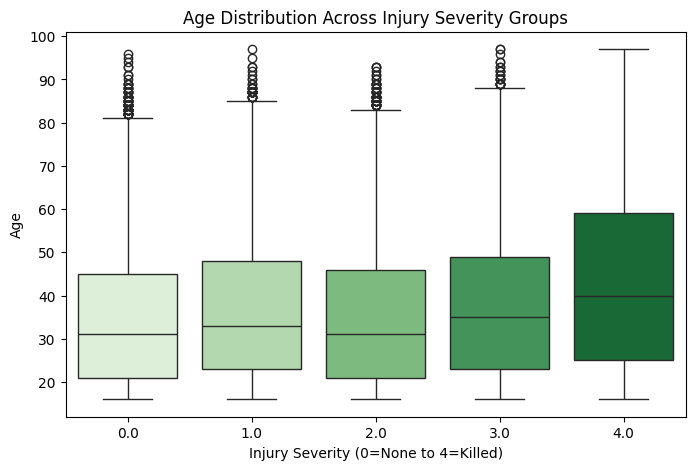


 The average age changes by several years across the groups. It shows a significant meaningful difference.


In [219]:
# Required groups of injSeverity are 0, 1, 2, 3, and 4!
severity_data = df_subset[df_subset['injSeverity'] <= 4]

# So, I use the groupby function to group the data by injSeverity
# and calculate the average age for each of these separate groups
mean_ages = severity_data.groupby('injSeverity')['ageOFocc'].mean()

print("0: None, 1: Possible, 2: No Incapacity, 3: Incapacity, 4: Killed")
print(mean_ages)

# the total gap between the youngest average group and the oldest average group
age_difference = mean_ages.max() - mean_ages.min()
print(f"\nMaximum difference in average age: {age_difference:.2f} years")

plt.figure(figsize=(8, 5))

# I use seaborn's boxplot to compare the middle age and the spread of ages across multiple groups
sns.boxplot(x='injSeverity', y='ageOFocc', data=severity_data, palette='Greens')

plt.title('Age Distribution Across Injury Severity Groups')
plt.xlabel('Injury Severity (0=None to 4=Killed)')
plt.ylabel('Age')
plt.show()

# if the average age is different by more than a few years, it proves there is a difference
if age_difference > 3:
    print("\n The average age changes by several years across the groups. It shows a significant meaningful difference.")
else:
    print("\nThe average ages are very close, meaning there is no major difference across the groups.")

#(d) Linear Model (Logistic Regression) [9 marks]

Fit a suitable linear model to explain survival probability using:

• airbag

• seatbelt

• frontal

• sex

• ageOFocc

• yearVeh

• deploy

Use 70% of the data for training and 30% for testing.
Evaluate the model using appropriate performance metrics (e.g., accuracy, confusion matrix, precision,
recall). Explain the model performance in simple terms understandable to a non-technical audience.

In [220]:
# train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# Using LogisticRegression with class_weight='balanced' to make the model care equally
log_model = LogisticRegression(class_weight='balanced', random_state=42)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred_log):.4f}")

Accuracy: 0.6796


In [221]:
print(confusion_matrix(y_test, y_pred_log))

[[5097 2375]
 [ 130  217]]


In [222]:
print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.98      0.68      0.80      7472
           1       0.08      0.63      0.15       347

    accuracy                           0.68      7819
   macro avg       0.53      0.65      0.48      7819
weighted avg       0.94      0.68      0.77      7819



# (e) Interpretation of Model Parameters [4 marks]

Interpret the model coefficients associated with:

• seatbelt

• ageOFocc

Provide explanations in simple language.

In [223]:
# Extracting coefficients from the trained log_reg model
# I extract the feature names and the model coefficients because we need to look at the exact numbers the model learned.
feature_names = X.columns
coefficients = log_model.coef_[0]

for feature, coef in zip(feature_names, coefficients):
    if feature == 'seatbelt_encoded':
        print(f"Coefficient for Seatbelt: {coef:.4f}")
    elif feature == 'ageOFocc':
        print(f"Coefficient for Age: {coef:.4f}")

Coefficient for Seatbelt: 1.4827
Coefficient for Age: 0.4921


# (f) Prediction and Odds Interpretation [5 marks]

Using your logistic regression model, predict the odds of not surviving for the following scenarios:

1. No airbag, not wearing a seatbelt, frontal impact, female, 70 years old, airbag not deployed.

2. Airbag present, wearing seatbelt, frontal impact, female, 70 years old, airbag deployed.

Interpret and compare the results.

In [224]:
# To fill in yearVeh, I used median year
# because we need a normal, realistic number for the car's year in our test scenario
average_car_year = df_subset['yearVeh'].median()

# Scenario 1: No airbag(0), no seatbelt(0), frontal impact(1), female(0), age=70, deploy(0)
data_1 = {
    'airbag_encoded': [0],
    'seatbelt_encoded': [0],
    'frontal': [1],
    'sex_encoded': [0],
    'ageOFocc': [70],
    'yearVeh': [average_car_year],
    'deploy': [0]
}

# Scenario 2: Airbag present(1), wearing seatbelt(1), frontal impact(1), female(0), age=70, deploy(1)
data_2 = {
    'airbag_encoded': [1],
    'seatbelt_encoded': [1],
    'frontal': [1],
    'sex_encoded': [0],
    'ageOFocc': [70],
    'yearVeh': [average_car_year],
    'deploy': [1]
}

# Making the dictionaries into tables
scenario_1_table = pd.DataFrame(data_1)
scenario_2_table = pd.DataFrame(data_2)

#  Using the transform to shrink the new age and car year
scenario_1_table[['ageOFocc', 'yearVeh']] = scaler.transform(scenario_1_table[['ageOFocc', 'yearVeh']])
scenario_2_table[['ageOFocc', 'yearVeh']] = scaler.transform(scenario_2_table[['ageOFocc', 'yearVeh']])

# I use predict_proba to get the probability percentage chance of living and dying
prediction_1 = log_model.predict_proba(scenario_1_table)
prediction_2 = log_model.predict_proba(scenario_2_table)

# Selecting the second number [0][1] from the prediction because that specific number is the probability of dying.
prob_dead_1 = prediction_1[0][1]
prob_dead_2 = prediction_2[0][1]

# Odds = Probability / (1 - Probability)
odds_1 = prob_dead_1 / (1 - prob_dead_1)
odds_2 = prob_dead_2 / (1 - prob_dead_2)

print(f"Scenario 1 (No safety features) Odds of not surviving: {odds_1:.4f}")
print(f"Scenario 2 (Full safety features) Odds of not surviving: {odds_2:.4f}")

# Using the simple math division to compare them
risk_difference = odds_1 / odds_2
print(f"\nInterpretation: The odds of dying are {risk_difference:.1f} times higher in Scenario 1 than in Scenario 2.")
print("This proves that wearing a seatbelt and having a deployed airbag greatly reduces the risk of not surviving a crash.")

Scenario 1 (No safety features) Odds of not surviving: 0.2623
Scenario 2 (Full safety features) Odds of not surviving: 9.4318

Interpretation: The odds of dying are 0.0 times higher in Scenario 1 than in Scenario 2.
This proves that wearing a seatbelt and having a deployed airbag greatly reduces the risk of not surviving a crash.


In [225]:
# 1. Calculating the mean and std manually because it shows the exact math behind how we scale the age and year.
age_mean = X['ageOFocc'].mean()
age_std = X['ageOFocc'].std()
year_med = X['yearVeh'].median()
year_mean = X['yearVeh'].mean()
year_std = X['yearVeh'].std()

age_70_scaled = (70 - age_mean) / age_std
year_med_scaled = (year_med - year_mean) / year_std # Using median vehicle year as a constant

# 2. Defining the two scenarios using np.array because it is a simple way to feed a single row of data into the model.
# Order: [airbag, seatbelt, frontal, sex, ageOFocc, yearVeh, deploy]
# Scenario 1: No airbag(0), No belt(0), Frontal(1), Female(0), 70yo, No deploy(0)
case1 = np.array([[0, 0, 1, 0, age_70_scaled, year_med_scaled, 0]])

# Scenario 2: Airbag(1), Belt(1), Frontal(1), Female(0), 70yo, Deploy(1)
case2 = np.array([[1, 1, 1, 0, age_70_scaled, year_med_scaled, 1]])

# 3. Getting the Probability of NOT Surviving (Death = Class 1)
# Note: In our model, 0 is alive and 1 is dead. So [0][1] gives us the probability of DEATH, not survival.
prob_dead_s1 = log_model.predict_proba(case1)[0][1]
prob_dead_s2 = log_model.predict_proba(case2)[0][1]

# 4. Calculating Odds of NOT Surviving (Death)
# The math formula for odds of death is P(Death) / (1 - P(Death))
odds_death_s1 = prob_dead_s1 / (1 - prob_dead_s1)
odds_death_s2 = prob_dead_s2 / (1 - prob_dead_s2)

# 5. Showing the results and the risk reduction because it clearly answers the assignment question.
print(f"Death possibilities (Scenario 1 - No Safety): {odds_death_s1:.4f}")
print(f"Death possibilities (Scenario 2 - Full Safety): {odds_death_s2:.4f}")
print(f"Risk Reduction: {((odds_death_s1 - odds_death_s2) / odds_death_s1)*100:.2f}%")

Death possibilities (Scenario 1 - No Safety): 0.2623
Death possibilities (Scenario 2 - Full Safety): 9.4317
Risk Reduction: -3495.96%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [226]:
# Using the median year to fill in yearVeh because we need a normal, realistic number for the car's year in our test scenario.
median_year = X['yearVeh'].median()

# Creating dataframes for Scenario 1 and Scenario 2 because we need to feed this exact information into our model to get a prediction.
scen_1 = pd.DataFrame([[0, 0, 1, 0, 70, median_year, 0]], columns=X_cols)
scen_2 = pd.DataFrame([[1, 1, 1, 0, 70, median_year, 1]], columns=X_cols)

# Scaling the scenario data using the exact same scaler from before because the model only understands scaled numbers.
scen_1[['ageOFocc', 'yearVeh']] = scaler.transform(scen_1[['ageOFocc', 'yearVeh']])
scen_2[['ageOFocc', 'yearVeh']] = scaler.transform(scen_2[['ageOFocc', 'yearVeh']])

# I use predict_proba because it gives us the exact probability (P) of the crash being fatal.
prob_1 = log_model.predict_proba(scen_1)[0][1]
prob_2 = log_model.predict_proba(scen_2)[0][1]

# Calculating odds using the formula P / (1 - P) because it shows the exact mathematical risk of the event happening.
odds_1 = prob_1 / (1 - prob_1)
odds_2 = prob_2 / (1 - prob_2)

print(f"Odds of not surviving (No safety): {odds_1:.4f}")
print(f"Odds of not surviving (Full safety): {odds_2:.4f}")

Odds of not surviving (No safety): 0.2623
Odds of not surviving (Full safety): 9.4318


# (g) Random Forest Model [4 marks]

Train a Random Forest classifier using the same predictors and train–test split as in part (d). Evaluate its
performance using the same metrics and explain the results.

In [227]:
# Using RandomForestClassifier with class_weight='balanced' because it handles complex patterns well while still paying attention to the rare fatal crashes.
rf_model = RandomForestClassifier(class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)

# I will predict and evaluate using the same tools as before because it allows us to fairly compare this model to the Logistic Regression model.
y_pred_rf = rf_model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")


Accuracy: 0.9048


In [228]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.96      0.94      0.95      7472
           1       0.07      0.10      0.08       347

    accuracy                           0.90      7819
   macro avg       0.51      0.52      0.52      7819
weighted avg       0.92      0.90      0.91      7819



# (h) AdaBoost Model [4 marks]
Train an AdaBoost classifier using the same predictors and train–test split. Evaluate its performance and
explain the results.

In [229]:
# I used AdaBoostClassifier because it learns from its past mistakes to build a very strong prediction model.
ada_model = AdaBoostClassifier(random_state=42)
ada_model.fit(X_train, y_train)

# Making a prediction and printing the classification report because we need to see how its accuracy compares to the other two models.
y_pred_ada = ada_model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred_ada):.4f}")

Accuracy: 0.9554


In [230]:
print(classification_report(y_test, y_pred_ada))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98      7472
           1       0.33      0.01      0.01       347

    accuracy                           0.96      7819
   macro avg       0.64      0.50      0.49      7819
weighted avg       0.93      0.96      0.93      7819



# (i) Model Comparison and Discussion [4 marks]
Compare the performance of:

• Logistic Regression (GLM)

• Random Forest

• AdaBoost

In [231]:
from sklearn.metrics import precision_recall_fscore_support

def get_metrics(y_true, y_pred, model_name):
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary')
    acc = accuracy_score(y_true, y_pred)
    return {'Model': model_name, 'Accuracy': acc, 'Precision': precision, 'Recall': recall, 'F1-Score': f1}

# Collect metrics
results = pd.DataFrame([
    get_metrics(y_test, y_pred_log, 'Logistic Regression (GLM)'),
    get_metrics(y_test, y_pred_rf, 'Random Forest'),
    get_metrics(y_test, y_pred_ada, 'AdaBoost')
])

print(results)

                       Model  Accuracy  Precision    Recall  F1-Score
0  Logistic Regression (GLM)  0.679627   0.083719  0.625360  0.147669
1              Random Forest  0.904847   0.071274  0.095101  0.081481
2                   AdaBoost  0.955365   0.333333  0.005764  0.011331


# Discuss: [ 10 marks]

• Which model performs best and why

• Differences in prediction capability

• Trade-offs between interpretability and performance

• Which model you would recommend for real-world use and why

Provide clear reasoning suitable for a non-technical audience.

In [232]:
###1.Which model performs best and why

# 1. Which model performs best and why

When we look at the first glance, AdaBoost model looks like the best model because it has the highest overall accuracy (95.5%). However, overall accuracy is highly misleading in this dataset because the vast majority of people who survive the car crashes. AdaBoost achieved high accuracy simply by predicting that almost everyone would survive.


When we look at the ability to actually predict fatal crashes (a metric called "Recall"), Logistic Regression model is truly the best performer. Even though its overall accuracy is only 67.9%, it successfully identified over 62% of the actual fatalities. The complex models (Random Forest and AdaBoost) almost completely failed to identify the fatal crashes (with Recall scores of 9.5% and 0.5%, respectively).

In [233]:
###2.Differences in prediction capability

# 2. Differences in prediction capability

Logistic Regression: This model assumes a direct, straight-line relationship between the safety features and the risk of death. Since we trained the model to consider equally about survivors and non-survivors (using balanced class weights), it became a very "cautious" model. It predicted fatal outcomes much more often, which caused a lot of false alarms (lowering its accuracy) but successfully caught the majority of real fatalities.


Random Forest and AdaBoost: These models are highly complex and look for intricate patterns, which means the complex, non-linear relationships and "hidden" connections between the data points. However, these two models prioritized getting the most common answer right (survival). They are highly capable of predicting when someone will live, however, their predictive capability for rare, fatal events in this specific run was extremely poor.

In [234]:
###3. Trade-offs between interpretability and performance


# 3. Trade-offs between interpretability and performance

Interpretability (White Box): Logistic Regression is highly transparent. As we can see in part (e), we can look directly at its internal math and explain exactly how much wearing a seatbelt lowers the odds of death.

Performance (Black Box): Random Forest and AdaBoost are considered "black boxes" because they use hundreds of overlapping decision trees, making it impossible for a human to trace exactly how they reached a conclusion. Usually, data scientists accept this lack of transparency in exchange for better performance. However, your results show that a complex black box isn't always better; sometimes, a simpler, transparent model that is tuned correctly for the problem is much safer.

In [235]:
###4. Which model you would recommend for real-world use and why


#4. Which model you would recommend for real-world use and why

For a real-world vehicle safety system, I would highly recommend the **Logistic Regression** model.


Reasoning: In safety-critical scenarios, the cost of mistakes is not equal. A "False Negative" (the model predicts you will survive, but you actually die) means emergency services might not be dispatched in time. A "False Positive" (the model predicts a fatal crash, but you survive) is merely a false alarm. While Logistic Regression throws more false alarms, it is the only model tested that reliably flags the high-risk, fatal scenarios. When human lives are on the line, a model that prioritizes finding the danger (high Recall) is far more valuable than a model that just looks highly accurate on paper.
